# Adaptive mapping workflow test 2

This test is using RESTORE+ dataset using Jawa-Bali as the AOI.

In [1]:
#This code is used if the notebook is implemented in github codespace. Just remove the (#)
# !python -m pip install .. --quiet

# Import GEE account setting from luma-stack

In [2]:
# Use EE initialization from luma_ge
import ee 
import luma_ge

# Autheticate using service account (json file)

service_account_path = '../auth/wall2wallrmap.json'
luma_ge.initialize_with_service_account(service_account_path)

#Check authentication status
status = luma_ge.get_auth_status()
print(f"Initialized: {status['initialized']}")
print(f"Authenticated: {status['authenticated']}")
if status['project']:
    print(f"Project: {status['project']}")


Service account initialization failed: Caller does not have required permission to use project epistem-490415. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=epistem-490415 and then retry. Propagation of the new permission may take a few minutes.


Initialized: True
Authenticated: True
Project: projects/epistem-490415/assets/RESTORE


# Upload AOI

AOI is imported from RESTORE+ asset of Jawa-Bali region

In [3]:
region_name = 'JawaBali'
regions_fc   = ee.FeatureCollection(
        "users/hadicu06/IIASA/RESTORE/vector_datasets/classification_regions")
aoi = (regions_fc
                   .filter(ee.Filter.eq('region_name', region_name))
            )

In [4]:
# Clip to 10 x 10 km

bbox = (aoi
    .geometry()
    .centroid()
    .buffer(20000)   # 20 km radius
    .bounds()       # → 40 km x 40 km box
)

# Optional: clipped AOI
clipped_aoi = (
    ee.FeatureCollection("users/hadicu06/IIASA/RESTORE/vector_datasets/classification_regions")
    .filter(ee.Filter.eq('region_name', region_name))
    .geometry()
    .intersection(bbox, ee.ErrorMargin(1))
)

# Return as a feature collection (for compatibility with later steps)
clipped_aoi = ee.FeatureCollection([
    ee.Feature(clipped_aoi)
])

# Collect satellite images

In [5]:
year = 2018

# Use embedding dataset
emb = (ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filterBounds(clipped_aoi)
)

# Annual embedding composite
composite = emb.median().clip(clipped_aoi)

# Inspect band names (important for this dataset)
# print(composite.bandNames().getInfo())

# Keep all embedding dimensions
stacked_landsat = composite

# Step 1a: Identify elements and properties
This step will identify the elements and properties that were defined in Step 0.
This step will be skipped in the testing and the identification will be done manually

# Step 1b: Classification Ruleset

Define all the functions to turn class definition into rulesets.

In [19]:
from luma_ge.modular_workflow import load_hierarchical_scheme

tree = load_hierarchical_scheme("../data/test_data/RESTORE_test/hierarchical_scheme_restore.csv")

2026-04-13 00:06:01,834 - load_hierarchical_scheme - INFO - Loaded hierarchical scheme: 12 nodes (5 splits, 7 leaves)


# Step 2: Build modular reference data

This step uploads the reference data that contains UML information inside its attribute table

## Use pre-built modular training data

Use this chunk to load the modular training data that was prepared outside of this workflow

In [7]:
from luma_ge.modular_workflow import load_modular_training_data

data = load_modular_training_data(
    shp_path="../data/test_data/RESTORE_test/JawaBali_RS_2018_targeted_allclasses1.shp",
    aoi = clipped_aoi
)

training_gdf = data["gdf"]


# Only select some of the primitives

keep_cols = [
    "tree_pres_", "treecover", "treeheight",
    "built_pres",
    "geometry"
]

training_gdf_filter = training_gdf[[col for col in keep_cols if col in training_gdf.columns]]

print(training_gdf_filter.columns.tolist())

['tree_pres_', 'treecover', 'treeheight', 'built_pres', 'geometry']


In [8]:
# # Minimize the number of samples for trial run

# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import MinMaxScaler #not included in luma-ge if you're using luma-ge env
# from sklearn.cluster import MiniBatchKMeans

# # Select numeric columns only (exclude geometry)
# feature_cols = [c for c in training_gdf.columns if c != "geometry"]

# df = training_gdf[feature_cols].copy()

# # Normalize features to [0, 1]
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(df)

# # Number of samples desired
# n_samples = 10000

# # Fit MiniBatchKMeans (efficient for large datasets)
# kmeans = MiniBatchKMeans(
#     n_clusters=n_samples,
#     random_state=42,
#     batch_size=2048,
#     n_init="auto"
# )

# labels = kmeans.fit_predict(X_scaled)

# # For each cluster, pick the closest point to centroid
# selected_indices = []

# for i in range(n_samples):
#     cluster_indices = np.where(labels == i)[0]
    
#     if len(cluster_indices) == 0:
#         continue
    
#     cluster_points = X_scaled[cluster_indices]
#     centroid = kmeans.cluster_centers_[i]
    
#     # Find closest point to centroid
#     distances = np.linalg.norm(cluster_points - centroid, axis=1)
#     closest_idx = cluster_indices[np.argmin(distances)]
    
#     selected_indices.append(closest_idx)

# # Create sampled dataframe
# sampled_gdf = training_gdf.iloc[selected_indices].reset_index(drop=True)

# print("Final sampled size:", len(sampled_gdf))

In [9]:
from luma_ge.input_utils import EE_converter

training_fc = EE_converter().convert_roi_gdf(training_gdf_filter)


features_list = training_fc.limit(100).getInfo()
for f in features_list['features']:
    print(f['properties'])


INFO: Converting training data to Earth Engine FeatureCollection...
2026-04-12 23:39:38,472 - luma_ge.input_utils - INFO - Converting training data to Earth Engine FeatureCollection...
INFO: SUCCESS: Successfully converted 412 features to Earth Engine FeatureCollection
2026-04-12 23:39:38,591 - luma_ge.input_utils - INFO - SUCCESS: Successfully converted 412 features to Earth Engine FeatureCollection


{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.036819006437436, 'tree_pres_': 0.392999957194552, 'treecover': 25, 'treeheight': 0}
{'built_pres': 0.03144976173644, 'tree_pres_': 0.741255085740704, 'treecover': 19, 'treeheight': 21}
{'built_pres': 0.03144976173644, 'tree_pres_': 0.741255085740704, 'treecover': 19, 'treehei

In [ ]:

# The sampled training data has produced probability value, but since we need a fake data that represent
# the crowd sourced training data (only accepts binary value), we will apply a threshold to convert the probability value into binary value (present/absent)

# Compute mean values for each primitive to use as thresholds
prop_names = training_fc.first().propertyNames().remove('system:index').getInfo()

means = {}
for prop in prop_names:
    means[prop] = training_fc.aggregate_median(prop).getInfo()

def reclassify_feature(feature):
    means_dict = ee.Dictionary(means)
    prop_names = feature.propertyNames()
    prop_names = prop_names.remove('system:index')
    
    def process_column(col, feat):
        col = ee.String(col)
        feat = ee.Feature(feat)

        raw_value = feat.get(col)
        value = ee.Number.parse(raw_value) # parse to number
                
        # Check if value is within [0,1]
        in_range = value.gte(0).And(value.lte(1))
        
        # Get the mean threshold for this primitive
        threshold = means_dict.get(col)
        
        # Apply threshold only if in range
        new_value = ee.Algorithms.If(
            in_range,
            ee.Algorithms.If(value.gte(threshold), 1, 0),
            value  
        )
        
        return feat.set(col, new_value)
    
    return ee.Feature(prop_names.iterate(process_column, feature))

training_fc = training_fc.map(reclassify_feature)

features_list = training_fc.limit(100).getInfo()
for f in features_list['features']:
    print(f['properties'])

{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 25, 'treeheight': 0}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 19, 'treeheight': 21}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 19, 'treeheight': 21}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 9, 'treeheight': 16}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 9, 'treeheight': 16}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 9, 'treeheight': 16}
{'built_pres': 1, 'tree_pres_': 1, 'treecover': 9, 'treeheight': 16}
{'built_pres': 1, 'tree_pres_': 

In [ ]:
# Check distribution of each property after reclassification
prop_names = training_fc.first().propertyNames()
prop_names = prop_names.remove('system:index')
prop_names = prop_names.getInfo()

print("Reclassified property distributions:")
for prop in prop_names:
    hist = training_fc.aggregate_histogram(prop).getInfo()
    print(f"=== {prop} ===")
    print(hist)
    print()

Reclassified property distributions:
=== built_pres ===
{'1': 412}

=== tree_pres_ ===
{'1': 412}

=== treecover ===
{'10': 14, '11': 7, '12': 61, '13': 32, '14': 47, '15': 63, '16': 28, '17': 11, '18': 16, '19': 2, '20': 48, '23': 7, '25': 29, '8': 20, '9': 27}

=== treeheight ===
{'0': 18, '10': 29, '11': 7, '12': 25, '13': 21, '14': 21, '15': 22, '16': 30, '17': 21, '2': 46, '21': 2, '3': 30, '4': 15, '5': 14, '6': 36, '7': 8, '8': 23, '9': 44}



# Step 3b: Generate primitive layers

## Probabilistic primitive layers

In [12]:
from luma_ge.modular_workflow import PrimitiveLayerTrainer

trainer = PrimitiveLayerTrainer(image=stacked_landsat, roi=training_fc, scale = 30)
# Automatically prints:
#   tree_pres   → binary
#   veg_height  → continuous
#   water_pres  → binary

prob_layers     = trainer.train_all_mc()
# Check the generated primitive layers

print(prob_layers.keys())
primitive_stack_mc = ee.Image.cat(list(prob_layers.values()))

2026-04-12 23:39:47,242 - PrimitiveLayerTrainer - INFO - Detected primitives: ['built_pres', 'tree_pres_', 'treecover', 'treeheight']
2026-04-12 23:39:47,244 - PrimitiveLayerTrainer - INFO -   built_pres                → binary
2026-04-12 23:39:47,245 - PrimitiveLayerTrainer - INFO -   tree_pres_                → binary
2026-04-12 23:39:47,246 - PrimitiveLayerTrainer - INFO -   treecover                 → continuous
2026-04-12 23:39:47,247 - PrimitiveLayerTrainer - INFO -   treeheight                → continuous
2026-04-12 23:39:47,248 - PrimitiveLayerTrainer - INFO - Starting Monte Carlo training for all primitives
2026-04-12 23:39:47,249 - PrimitiveLayerTrainer - INFO - Training [PROBABILITY]: built_pres
2026-04-12 23:39:47,250 - PrimitiveLayerTrainer - INFO -     → Start MC training: built_pres (PROBABILITY)
2026-04-12 23:39:47,252 - PrimitiveLayerTrainer - INFO -   -> Training model for built_pres (PROBABILITY)
2026-04-12 23:39:47,253 - PrimitiveLayerTrainer - INFO -   -> Applying 

dict_keys(['built_pres', 'tree_pres_', 'treecover', 'treeheight'])


In [13]:
from luma_ge.modular_workflow import HierarchicalRuleSetClassifier, _ee_image_to_numpy
from luma_ge.modular_workflow_thresholdoptimiser import ThresholdOptimiser, describe_primitives

clf = HierarchicalRuleSetClassifier(
    primitive_image=primitive_stack_mc,
    scheme_df=tree,
    primitive_types= trainer.primitive_types,
    aoi=clipped_aoi)

band_arrays = clf._download_band_arrays(scale=trainer.scale)

2026-04-12 23:39:48,006 - HierarchicalRuleSetClassifier - INFO -   Fetching 4 bands at 30m...
2026-04-12 23:39:57,774 - HierarchicalRuleSetClassifier - INFO -   Downloaded: 1337 x 1338 px (1,788,906 pixels per band)


In [14]:
import rasterio
import io
import requests
import numpy as np

# Download all bands individually (working approach from diagnostic cell)
aoi_geom = clipped_aoi.geometry()
all_band_names = primitive_stack_mc.bandNames().getInfo()

band_arrays = {}

print(f"Downloading {len(all_band_names)} bands individually...")

for band_name in all_band_names:
    print(f"\n  {band_name}...", end=" ", flush=True)
    
    url = primitive_stack_mc.select([band_name]).getDownloadURL({
        "bands":  [band_name],
        "region": aoi_geom,
        "scale":  trainer.scale,
        "format": "GEO_TIFF",
        "crs":    "EPSG:4326",
    })
    
    response = requests.get(url, stream=True, timeout=300)
    response.raise_for_status()
    raw = response.content
    
    # Read with rasterio
    with rasterio.open(io.BytesIO(raw)) as src:
        raw_data = src.read(1).astype(np.float32)
        band_arrays[band_name] = raw_data
        
        # Print statistics for this band
        min_val = np.nanmin(raw_data)
        max_val = np.nanmax(raw_data)
        mean_val = np.nanmean(raw_data)
        print(f"min={min_val:.6f}, max={max_val:.6f}, mean={mean_val:.6e}")

print(f"\n✓ All {len(band_arrays)} bands downloaded successfully")
print(f"\nFinal band_arrays keys: {list(band_arrays.keys())}")
print(f"Shape per band: {next(iter(band_arrays.values())).shape}")



  built_pres... min=0.000000, max=0.980454, mean=4.726433e-06

  tree_pres_... min=0.000000, max=0.983194, mean=8.206095e-06

  treecover... min=0.000000, max=25.000000, mean=3.264454e-04

  treeheight... min=0.000000, max=17.062696, mean=1.670736e-04

✓ All 4 bands downloaded successfully

Final band_arrays keys: ['built_pres', 'tree_pres_', 'treecover', 'treeheight']
Shape per band: (1337, 1338)


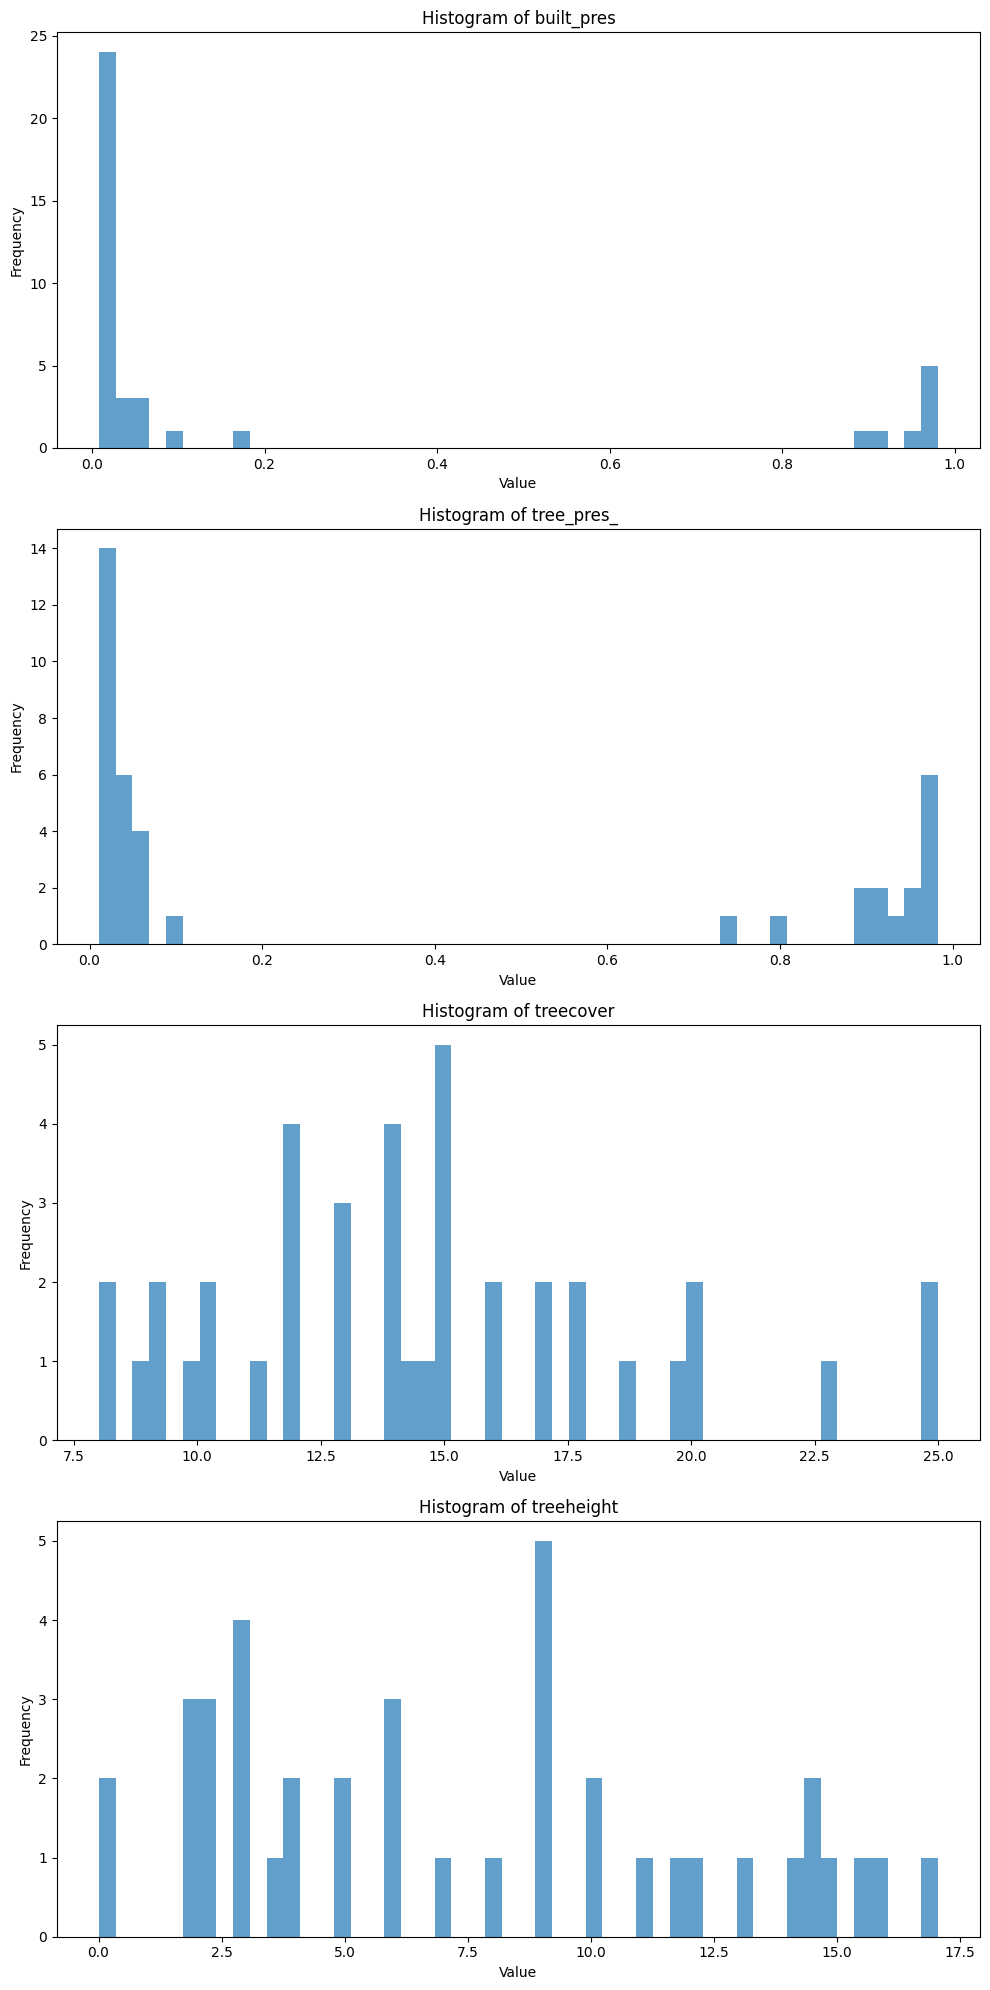

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize histograms of band_arrays to confirm distributions
fig, axes = plt.subplots(nrows=len(band_arrays), figsize=(10, 5*len(band_arrays)))

for i, (name, arr) in enumerate(band_arrays.items()):
    flat = arr.ravel()
    flat = flat[np.isfinite(flat)  & (flat != 0)]  # exclude NaN and zeros # exclude NaN/masked pixels
    axes[i].hist(flat, bins=50, alpha=0.7)
    axes[i].set_title(f'Histogram of {name}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Quick check on the statistics of the generated primitive layers (min, max, mean, stddev)
for name, img in prob_layers.items():

    stats = img.reduceRegion(
        reducer=ee.Reducer.minMax()
            .combine(ee.Reducer.mean(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=clipped_aoi,
        scale=trainer.scale,
        maxPixels=1e13
    ).getInfo()

    min_val = stats.get(f"{name}_min")
    max_val = stats.get(f"{name}_max")
    mean_val = stats.get(f"{name}_mean")
    std_val = stats.get(f"{name}_stdDev")

    print(f"{name:20s} min={min_val:.4f} max={max_val:.4f} mean={mean_val:.4f} std={std_val:.4f}")



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize histograms of prob_layers using Earth Engine sampling
fig, axes = plt.subplots(nrows=len(prob_layers), figsize=(10, 5*len(prob_layers)))

for i, (name, img) in enumerate(prob_layers.items()):
    # Get histogram from EE
    hist_dict = img.reduceRegion(
        reducer=ee.Reducer.histogram(maxBuckets=50),
        geometry=clipped_aoi,
        scale=trainer.scale,
        maxPixels=1e13
    ).getInfo()
    
    # Extract histogram data
    hist = hist_dict[name]
    bucketMeans = np.array(hist['bucketMeans'])
    bucketCounts = np.array(hist['histogram'])
    
    # Plot
    axes[i].bar(bucketMeans, bucketCounts, width=(bucketMeans[1]-bucketMeans[0]) if len(bucketMeans)>1 else 0.1, alpha=0.7)
    axes[i].set_title(f'Histogram of {name} (EE sampled)')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Testing: optimise the threshold in scheme

In [ ]:
# Get aoi_bounds from your AOI geometry
bounds_info = clipped_aoi.geometry().bounds().getInfo()["coordinates"][0]
xs = [p[0] for p in bounds_info]
ys = [p[1] for p in bounds_info]
aoi_bounds = (min(xs), min(ys), max(xs), max(ys))

In [ ]:
opt = ThresholdOptimiser(
    scheme_csv       = '../data/test_data/RESTORE_test/hierarchical_scheme_restore.csv',
    band_arrays      = band_arrays,
    # node_bounds      = node_bounds,
    aoi_bounds       = aoi_bounds,
    training_gdf     = data['gdf'],
    class_col        = 'LULC_Type',
    balance_weight   = 0.5,
    alignment_weight = 0.5,
)
optimised_df = opt.run()
optimised_df.to_csv('scheme_optimised.csv', index=False)


# Step 4: Classification

## Generate using Monte Carlo simulation and probabilistic layers

### Trial using tiled export for big AOI

In [21]:
"""
Scalable replacements for the three memory-critical methods inside
HierarchicalRuleSetClassifier, plus a new classify_monte_carlo_tiled()
entry point for large AOIs.

Root causes addressed
---------------------
1. getDownloadURL fails for 27 bands over a large AOI (>32MB limit).
   Fix: export to Drive once, reload from local GeoTIFF.
   Fallback: download band-by-band in groups of max_bands_per_request.

2. MC loop RAM scales as n_classes × H × W × int32 for counts array.
   For 10 classes and 1M pixels that is 40MB per run — manageable.
   But with tiling (fix 3) peak RAM per tile is bounded.

3. _numpy_to_ee_image serialises the entire class map as a Python list
   into a GEE API payload. For 500k+ pixels this hits GEE user memory.
   Fix: write result as GeoTIFF and upload via Cloud Storage, or just
   keep the result local and skip the ee.Image conversion entirely
   (the numpy array is the primary output).
"""

import io
import logging
import math
import os
import time
import zipfile
from pathlib import Path
from typing import Optional

import ee
import numpy as np
import pandas as pd
import rasterio
import requests
from rasterio.transform import from_bounds


logger_name = "HierarchicalRuleSetClassifier"


# ---------------------------------------------------------------------------
# Fix 1: band-by-band download with toDrive fallback
# ---------------------------------------------------------------------------

def _download_band_arrays_batched(
    primitive_image: ee.Image,
    aoi_geom,
    scale: int,
    max_bands_per_request: int = 5,
    logger=None,
) -> dict:
    """
    Download primitive bands in small batches to stay within GEE's
    32 MB per-request download limit.

    For 27 bands at 30m over a large AOI, requesting all bands at once
    will fail. Downloading in groups of max_bands_per_request keeps each
    request small enough to succeed.

    Parameters
    ----------
    primitive_image : ee.Image
        Full stacked primitive image.
    aoi_geom : ee.Geometry
        Clipped geometry — must be resolved before calling.
    scale : int
        Pixel scale in metres.
    max_bands_per_request : int
        Maximum bands per getDownloadURL call. Default 5.
        Reduce to 1–2 for very large AOIs or high-resolution datasets.
    logger : logging.Logger or None

    Returns
    -------
    dict[str, np.ndarray]
        All bands as float32 arrays.
    """
    log = logger or logging.getLogger(logger_name)
    all_band_names = primitive_image.bandNames().getInfo()
    n_bands        = len(all_band_names)
    n_batches      = math.ceil(n_bands / max_bands_per_request)

    log.info(
        f"  Downloading {n_bands} bands in {n_batches} batch(es) "
        f"of ≤{max_bands_per_request} (scale={scale}m)..."
    )

    band_arrays = {}

    for batch_idx in range(n_batches):
        batch_names = all_band_names[
            batch_idx * max_bands_per_request:
            (batch_idx + 1) * max_bands_per_request
        ]
        log.info(f"  Batch {batch_idx+1}/{n_batches}: {batch_names}")

        url = primitive_image.select(batch_names).getDownloadURL({
            "bands":  batch_names,
            "region": aoi_geom,
            "scale":  scale,
            "format": "GEO_TIFF",
            "crs":    "EPSG:4326",
        })

        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()
        raw = response.content

        if raw[:4] == b"PK\x03\x04":
            with zipfile.ZipFile(io.BytesIO(raw)) as zf:
                tif_names = sorted(
                    n for n in zf.namelist() if n.endswith(".tif")
                )
                for band_name, tif_name in zip(batch_names, tif_names):
                    with zf.open(tif_name) as f:
                        with rasterio.open(io.BytesIO(f.read())) as src:
                            band_arrays[band_name] = src.read(1).astype(np.float32)
        else:
            with rasterio.open(io.BytesIO(raw)) as src:
                for i, band_name in enumerate(batch_names, start=1):
                    band_arrays[band_name] = src.read(i).astype(np.float32)

    h, w = next(iter(band_arrays.values())).shape
    log.info(
        f"  All bands downloaded: {h}×{w} px "
        f"({h*w:,} pixels, {n_bands} bands, "
        f"~{h*w*n_bands*4/1e6:.1f} MB in RAM)"
    )
    return band_arrays


def _export_and_reload_band_arrays(
    primitive_image: ee.Image,
    aoi_geom,
    scale: int,
    export_path: str,
    drive_folder: str = "epistem_exports",
    description: str  = "primitive_stack",
    logger=None,
) -> dict:
    """
    Export the full primitive stack to Google Drive as a single GeoTIFF,
    then reload it from the downloaded local file.

    Use this for very large AOIs where even batched downloads fail, or
    when you want to persist the primitive stack across sessions (avoiding
    re-download for every scheme run).

    Parameters
    ----------
    primitive_image : ee.Image
        Full stacked primitive image.
    aoi_geom : ee.Geometry
    scale : int
    export_path : str
        Local path where the downloaded GeoTIFF will be saved.
        If the file already exists it is reloaded directly, skipping export.
    drive_folder : str
        Google Drive folder for the export task.
    description : str
        GEE task description (also the file name on Drive).
    logger : logging.Logger or None

    Returns
    -------
    dict[str, np.ndarray]
        All bands as float32 arrays.

    Notes
    -----
    This method starts the GEE export task and polls until complete.
    You must have the Google Drive API accessible and the file manually
    downloaded to export_path before this function can reload it.
    For automation, consider using geemap.ee_export_image() instead.
    """
    log  = logger or logging.getLogger(logger_name)
    path = Path(export_path)

    if path.exists():
        log.info(f"  Reloading existing primitive stack from '{export_path}'...")
        return _load_band_arrays_from_geotiff(str(path), log)

    log.info(
        f"  Exporting primitive stack to Drive (folder='{drive_folder}', "
        f"file='{description}.tif')..."
    )

    band_names = primitive_image.bandNames().getInfo()

    task = ee.batch.Export.image.toDrive(
        image       = primitive_image,
        description = description,
        folder      = drive_folder,
        region      = aoi_geom,
        scale       = scale,
        crs         = "EPSG:4326",
        fileFormat  = "GeoTIFF",
        maxPixels   = 1e10,
    )
    task.start()
    log.info(f"  Export task started: {task.id}")
    log.info(
        "  Download the file from Google Drive to "
        f"'{export_path}' then call this function again."
    )
    return {}  # caller must retry after manual download


def _load_band_arrays_from_geotiff(
    geotiff_path: str,
    logger=None,
) -> dict:
    """
    Load a multi-band GeoTIFF (e.g. from Export.toDrive) back into the
    band_arrays dict format expected by the MC loop.

    Parameters
    ----------
    geotiff_path : str
        Local path to the GeoTIFF file.

    Returns
    -------
    dict[str, np.ndarray]
    """
    log = logger or logging.getLogger(logger_name)
    band_arrays = {}

    with rasterio.open(geotiff_path) as src:
        band_names = list(src.descriptions)
        for i, name in enumerate(band_names, start=1):
            band_name = name if name else f"band_{i}"
            band_arrays[band_name] = src.read(i).astype(np.float32)

    h, w = next(iter(band_arrays.values())).shape
    log.info(
        f"  Loaded {len(band_arrays)} bands from '{geotiff_path}': "
        f"{h}×{w} px ({h*w:,} pixels)"
    )
    return band_arrays


# ---------------------------------------------------------------------------
# Fix 2: tiled MC loop
# ---------------------------------------------------------------------------

def classify_monte_carlo_tiled(
    classifier,
    n_iterations:  int   = 300,
    nodata_value:  float = 0.0,
    seed:          Optional[int] = 42,
    scale:         int   = 30,
    tile_size:     int   = 256,
    max_bands_per_request: int = 5,
    output_path:   Optional[str] = None,
) -> dict:
    """
    Memory-efficient Monte Carlo classification that processes the AOI
    in spatial tiles, keeping peak RAM bounded regardless of AOI size.

    Instead of loading all 27 bands × full AOI into RAM at once, each
    tile is downloaded, classified through all MC iterations, and then
    discarded before moving to the next tile. Only the final mode_map,
    entropy_map, and class_probs arrays for the completed tile are kept.

    Parameters
    ----------
    classifier : HierarchicalRuleSetClassifier
        Initialised classifier instance.
    n_iterations : int
        Number of Monte Carlo draws per tile.
    nodata_value : float
        Class ID for unassigned pixels.
    seed : int or None
        Base random seed. Each tile uses seed + tile_index for
        reproducibility while maintaining spatial independence.
    scale : int
        Pixel resolution in metres.
    tile_size : int
        Tile edge length in pixels. Default 256 (256×256 = 65k pixels).
        Reduce for very large AOIs or high band counts.
    max_bands_per_request : int
        Bands per getDownloadURL call within each tile. Default 5.
    output_path : str or None
        If provided, writes the final assembled mode_map as a GeoTIFF
        to this path. Avoids the ee.Array serialisation issue entirely.

    Returns
    -------
    dict with keys:
        'mode_map'    — (H, W) int array
        'entropy_map' — (H, W) float array (nats)
        'class_probs' — dict[class_id -> (H, W) float array]
        'n_iterations'— int

    Example
    -------
    >>> results = classify_monte_carlo_tiled(clf, n_iterations=300,
    ...                                      tile_size=256, scale=30)
    """
    log = logging.getLogger(logger_name)

    # --- Download full primitive stack in batches ----------------------------
    aoi_geom    = classifier._resolve_geometry()
    band_arrays = _download_band_arrays_batched(
        classifier.primitive_image,
        aoi_geom,
        scale,
        max_bands_per_request=max_bands_per_request,
        logger=log,
    )

    if not band_arrays:
        raise ValueError("No band arrays downloaded — check AOI and primitive_image.")

    # Validate binary bands only
    
    # classifier._validate_probability_range(band_arrays, classifier.primitive_types)

    sample_arr = next(iter(band_arrays.values()))
    H, W       = sample_arr.shape

    # Collect all leaf class IDs from the scheme
    leaf_nodes    = classifier.scheme_df[classifier.scheme_df["node_type"] == "leaf"]
    all_class_ids = sorted(leaf_nodes["class_id"].dropna().unique().tolist())
    if nodata_value not in all_class_ids:
        all_class_ids = [nodata_value] + all_class_ids
    n_classes       = len(all_class_ids)
    class_id_to_idx = {cid: i for i, cid in enumerate(all_class_ids)}

    # Pre-allocate output arrays for the full extent
    mode_map    = np.full((H, W), nodata_value, dtype=np.int32)
    entropy_map = np.zeros((H, W), dtype=np.float32)
    prob_arrays = {cid: np.zeros((H, W), dtype=np.float32)
                   for cid in all_class_ids}

    # Tile grid
    n_tiles_y = math.ceil(H / tile_size)
    n_tiles_x = math.ceil(W / tile_size)
    total_tiles = n_tiles_y * n_tiles_x
    log.info(
        f"Processing {total_tiles} tiles ({n_tiles_y}×{n_tiles_x}), "
        f"tile_size={tile_size}px, n_iterations={n_iterations}..."
    )

    tile_idx = 0
    for ty in range(n_tiles_y):
        for tx in range(n_tiles_x):
            r0 = ty * tile_size
            r1 = min(r0 + tile_size, H)
            c0 = tx * tile_size
            c1 = min(c0 + tile_size, W)
            th = r1 - r0
            tw = c1 - c0

            # Slice band arrays for this tile
            tile_bands = {
                name: arr[r0:r1, c0:c1]
                for name, arr in band_arrays.items()
            }

            # Per-tile count array — int16 saves RAM vs int32
            # (max value = n_iterations ≤ 32767 for int16)
            dtype = np.int16 if n_iterations <= 32767 else np.int32
            counts = np.zeros((n_classes, th, tw), dtype=dtype)
            rng    = np.random.default_rng(
                seed + tile_idx if seed is not None else None
            )

            for _ in range(n_iterations):
                sampled = classifier._sample_primitives(
                    tile_bands, rng, th, tw,
                    primitive_types             = classifier.primitive_types,
                    continuous_uncertainty_frac = classifier.continuous_uncertainty_frac,
                )
                iter_result = classifier._traverse_tree_numpy(
                    sampled, th, tw, nodata_value
                )
                for cid, idx in class_id_to_idx.items():
                    counts[idx] += (iter_result == cid).astype(dtype)

            # Aggregate tile results
            idx_to_class  = np.array(all_class_ids, dtype=float)
            tile_mode     = idx_to_class[np.argmax(counts, axis=0)].astype(np.int32)
            tile_probs    = counts.astype(np.float32) / n_iterations

            with np.errstate(divide="ignore", invalid="ignore"):
                log_p = np.where(tile_probs > 0, np.log(tile_probs), 0.0)
            tile_entropy = -np.sum(tile_probs * log_p, axis=0).astype(np.float32)

            # Write tile into full output arrays
            mode_map[r0:r1, c0:c1]    = tile_mode
            entropy_map[r0:r1, c0:c1] = tile_entropy
            for cid, idx in class_id_to_idx.items():
                prob_arrays[cid][r0:r1, c0:c1] = tile_probs[idx]

            tile_idx += 1
            if tile_idx % max(1, total_tiles // 10) == 0 or tile_idx == total_tiles:
                log.info(f"  Tile {tile_idx}/{total_tiles} complete.")

    # --- Optionally save as GeoTIFF (avoids ee.Array memory issue) ----------
    if output_path:
        _save_mode_map_as_geotiff(mode_map, output_path, aoi_geom, scale, log)

    log.info("Tiled MC classification complete.")
    return {
        "mode_map":     mode_map,
        "entropy_map":  entropy_map,
        "class_probs":  prob_arrays,
        "n_iterations": n_iterations,
    }


# ---------------------------------------------------------------------------
# Fix 3: save result as GeoTIFF instead of serialising to ee.Array
# ---------------------------------------------------------------------------

def _save_mode_map_as_geotiff(
    mode_map: np.ndarray,
    output_path: str,
    aoi_geom,
    scale: int,
    logger=None,
) -> str:
    """
    Write the mode_map numpy array as a GeoTIFF, computing the geotransform
    from the AOI bounds and pixel scale.

    This completely avoids the ee.Array serialisation that causes GEE
    user memory errors for large arrays. The GeoTIFF can be uploaded to
    GEE manually or via geemap if needed.

    Parameters
    ----------
    mode_map : np.ndarray
        (H, W) classification result array.
    output_path : str
        Destination file path (e.g. "results/mode_map_scheme1.tif").
    aoi_geom : ee.Geometry
        Used to derive geographic bounds for the GeoTIFF.
    scale : int
        Pixel size in metres (used for transform calculation).
    logger : logging.Logger or None

    Returns
    -------
    str
        The output_path that was written.
    """
    log = logger or logging.getLogger(logger_name)

    bounds = aoi_geom.bounds().getInfo()["coordinates"][0]
    xs     = [pt[0] for pt in bounds]
    ys     = [pt[1] for pt in bounds]
    west, east, south, north = min(xs), max(xs), min(ys), max(ys)

    H, W       = mode_map.shape
    transform  = from_bounds(west, south, east, north, W, H)

    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

    with rasterio.open(
        output_path,
        "w",
        driver    = "GTiff",
        height    = H,
        width     = W,
        count     = 1,
        dtype     = rasterio.int32,
        crs       = "EPSG:4326",
        transform = transform,
        compress  = "lzw",
    ) as dst:
        dst.write(mode_map.astype(np.int32), 1)
        dst.update_tags(scale_m=scale)

    size_mb = os.path.getsize(output_path) / 1e6
    log.info(f"  Saved mode_map → '{output_path}' ({size_mb:.1f} MB)")
    return output_path

In [ ]:
# manual edit
optimised_df = pd.read_csv('scheme_optimised.csv')

clf = HierarchicalRuleSetClassifier(
    primitive_stack_mc, optimised_df, clipped_aoi,
    primitive_types=trainer.primitive_types
)
results = classify_monte_carlo_tiled(
    clf, n_iterations=300,
    scale=30, tile_size=256,
    max_bands_per_request=4,
    output_path='results/mode_map_optimised.tif'
)


In [22]:
# Use non-optimised scheme for comparison

clf = HierarchicalRuleSetClassifier(
    primitive_stack_mc, tree, clipped_aoi,
    primitive_types=trainer.primitive_types
)
results_nonoptimised = classify_monte_carlo_tiled(
    clf, n_iterations=300,
    scale=30, tile_size=256,
    max_bands_per_request=4,
    output_path='results/mode_map_optimised.tif'
)

2026-04-13 00:06:22,619 - HierarchicalRuleSetClassifier - INFO -   Downloading 4 bands in 1 batch(es) of ≤4 (scale=30m)...
2026-04-13 00:06:22,620 - HierarchicalRuleSetClassifier - INFO -   Batch 1/1: ['built_pres', 'tree_pres_', 'treecover', 'treeheight']
2026-04-13 00:06:46,147 - rasterio._env - WARNING - CPLE_AppDefined in 73163ab8-22e6-48db-ac9b-eac104d34d68.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
2026-04-13 00:06:46,151 - rasterio._env - WARNING - CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
2026-04-13 00:06:46,229 - HierarchicalRuleSetClassifier - INFO -   All bands downloaded: 1337×1338 px (1,788,906 pixels, 4 bands, ~28.6 MB in RAM)
2026-04-13 00:06:46,234 - HierarchicalRuleSetClassifier - INFO - Processing 36 tiles (6×6), tile

# Optional step: validation

In [23]:
import numpy as np

raster = results_nonoptimised["mode_map"]

unique, counts = np.unique(raster, return_counts=True)

class_counts = dict(zip(unique, counts))

print("Pixel count per class:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count}")
 

Pixel count per class:
Class 0: 19
Class 1: 7
Class 2: 6
Class 4: 1788866
Class 8: 8


In [25]:
# Detailed statistics for classification results
import numpy as np

raster = results_nonoptimised["mode_map"]
entropy = results_nonoptimised["entropy_map"]

# Basic class statistics
unique_classes, class_counts = np.unique(raster, return_counts=True)
total_pixels = raster.size
n_classes = len(unique_classes)

print("=== CLASSIFICATION STATISTICS ===")
print(f"Total pixels: {total_pixels:,}")
print(f"Number of classes: {n_classes}")
print(f"Min class ID: {unique_classes.min()}")
print(f"Max class ID: {unique_classes.max()}")
print(f"Most frequent class: {unique_classes[np.argmax(class_counts)]} ({class_counts.max():,} pixels)")

print("\nClass distribution (%):")
for cls, count in zip(unique_classes, class_counts):
    percentage = (count / total_pixels) * 100
    print(f"Class {cls}: {count:,} pixels ({percentage:.2f}%)")

# Entropy statistics
print("\n=== ENTROPY STATISTICS ===")
print(f"Min entropy: {entropy.min():.4f}")
print(f"Max entropy: {entropy.max():.4f}")
print(f"Mean entropy: {entropy.mean():.4f}")
print(f"Std entropy: {entropy.std():.4f}")

# Spatial statistics
print("\n=== SPATIAL STATISTICS ===")
# Assuming 30m pixels (scale=30)
pixel_area_m2 = 30 * 30  # 900 m²
pixel_area_km2 = pixel_area_m2 / 1e6

print(f"Pixel resolution: 30m x 30m = {pixel_area_m2} m² = {pixel_area_km2:.4f} km²")
print(f"Total area: {total_pixels * pixel_area_km2:.2f} km²")

for cls, count in zip(unique_classes, class_counts):
    area_km2 = count * pixel_area_km2
    print(f"Class {cls} area: {area_km2:.2f} km²")

=== CLASSIFICATION STATISTICS ===
Total pixels: 1,788,906
Number of classes: 5
Min class ID: 0
Max class ID: 8
Most frequent class: 4 (1,788,866 pixels)

Class distribution (%):
Class 0: 19 pixels (0.00%)
Class 1: 7 pixels (0.00%)
Class 2: 6 pixels (0.00%)
Class 4: 1,788,866 pixels (100.00%)
Class 8: 8 pixels (0.00%)

=== ENTROPY STATISTICS ===
Min entropy: -0.0000
Max entropy: 1.0249
Mean entropy: 0.0000
Std entropy: 0.0019

=== SPATIAL STATISTICS ===
Pixel resolution: 30m x 30m = 900 m² = 0.0009 km²
Total area: 1610.02 km²
Class 0 area: 0.02 km²
Class 1 area: 0.01 km²
Class 2 area: 0.01 km²
Class 4 area: 1609.98 km²
Class 8 area: 0.01 km²


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

classes = [0, 1, 5, 8, 10]
cmap = plt.get_cmap("tab10", len(classes))

norm = mcolors.BoundaryNorm(classes + [11], cmap.N)

plt.imshow(results["mode_map"], cmap=cmap, norm=norm)
plt.colorbar(ticks=classes)
plt.title("Class Map (Discrete Colors)")
plt.show()